# **Sales Prediction Using Advertising Spend**
## A Marketing Mix Regression & Budget Scenario Analysis


**Objective:** Predict sales from advertising expenditure, quantify channel impact, compare regression approaches, simulate future advertising decisions, and translate the findings into actionable marketing recommendations.

---

> **Important data-scope note:** The supplied dataset contains `TV`, `Radio`, `Newspaper`, and `Sales` (plus an index column). It does **not** contain target-segment, customer-segment, platform-level digital channel, or date/time fields. Therefore, this notebook does not fabricate those variables. Instead, it uses the three observed advertising channels as the available marketing-mix predictors and explicitly identifies segment/platform/time data as a business data gap.

---

## 1. Business Problem & Analytical Questions

The task is to predict sales from advertising investment and use the results for marketing decisions.

This notebook answers five practical questions:

- **Prediction:** How accurately can sales be predicted from observed advertising spend?
- **Preparation:** Is the dataset clean and suitable for modeling?
- **Feature selection:** Which advertising channels provide the strongest predictive information?
- **Impact:** How does changing advertising expenditure alter predicted sales?
- **Decision support:** How could a marketer use the model to test budgets before spending them?

Because there is no date column, a conventional time-series forecast would not be statistically justified. The appropriate forecasting interpretation here is **regression-based scenario forecasting**: given a planned advertising budget, estimate the associated sales level.

## 2. Import Libraries

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import RFE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 3. Load the Dataset

In [2]:
df_raw = pd.read_csv("/kaggle/input/datasets/bumba5341/advertisingcsv/Advertising.csv")

In [3]:
df_raw.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df_raw.shape

(200, 5)

### Initial Dataset Interpretation

The dataset contains **200 observations and 4 columns** in the supplied file. The columns are an index-like field plus three advertising-spend variables (`TV`, `Radio`, `Newspaper`) and the target variable (`Sales`).

The index-like column is not a marketing predictor, so it will be removed rather than allowing an arbitrary row identifier to influence the model.

## 4. Data Audit & Cleaning

In [5]:
df = df_raw.copy()

# Standardize column names
df.columns = [str(c).strip() for c in df.columns]

# Remove common CSV index columns
index_like = [c for c in df.columns if c.lower().startswith("unnamed")]
if index_like:
    df = df.drop(columns=index_like)

required_cols = ["TV", "Radio", "Newspaper", "Sales"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Required columns are missing: {missing_required}")

# Convert required fields to numeric where possible
for col in required_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

audit = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum(),
    "Unique Values": df.nunique(),
    "Minimum": df.min(numeric_only=True),
    "Maximum": df.max(numeric_only=True)
})
display(audit)

print("Duplicate rows before cleaning:", df.duplicated().sum())
print("Rows with missing values before cleaning:", df.isna().any(axis=1).sum())

,Data Type,Missing Values,Unique Values,Minimum,Maximum
TV,float64,0,190,0.7,296.4
Radio,float64,0,167,0.0,49.6
Newspaper,float64,0,172,0.3,114.0
Sales,float64,0,121,1.6,27.0


Duplicate rows before cleaning: 0
Rows with missing values before cleaning: 0


In [6]:
# Remove duplicate records and rows with missing required values
before_rows = len(df)
duplicate_count = int(df.duplicated().sum())

df = df.drop_duplicates().dropna(subset=required_cols).reset_index(drop=True)

# Advertising spend cannot logically be negative
negative_counts = (df[["TV", "Radio", "Newspaper"]] < 0).sum()
negative_rows = int((df[["TV", "Radio", "Newspaper"]] < 0).any(axis=1).sum())

if negative_rows > 0:
    df = df[(df[["TV", "Radio", "Newspaper"]] >= 0).all(axis=1)].reset_index(drop=True)

after_rows = len(df)

print(f"Rows before cleaning: {before_rows}")
print(f"Duplicate rows removed: {duplicate_count}")
print(f"Rows removed for missing values / invalid numeric conversion: {before_rows - (before_rows - duplicate_count)}" if False else "")
print(f"Rows after cleaning: {after_rows}")
print("Negative advertising-spend rows removed:", negative_rows)
print("Remaining missing values:", int(df[required_cols].isna().sum().sum()))

display(df.describe().T.round(3))

Rows before cleaning: 200
Duplicate rows removed: 0

Rows after cleaning: 200
Negative advertising-spend rows removed: 0
Remaining missing values: 0


,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.042,85.854,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.264,14.847,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.554,21.779,0.3,12.750,25.75,45.100,114.0
Sales,200.0,14.022,5.217,1.6,10.375,12.90,17.400,27.0


### Cleaning Interpretation

The cleaning process checks duplicates, missing values, numeric types, and impossible negative advertising expenditures. Importantly, the supplied dataset is already complete: the three advertising variables and `Sales` contain no missing values, and the index-like field is removed because it has no business meaning.

The resulting modeling table therefore preserves the available observations rather than applying unnecessary imputation.

## 5. Exploratory Data Analysis

In [7]:
summary = df[required_cols].describe().T
summary["Coefficient of Variation (%)"] = summary["std"] / summary["mean"] * 100
display(summary.round(3))

print("Average advertising spend:")
display(df[["TV", "Radio", "Newspaper"]].mean().round(2).to_frame("Average Spend"))

print("Average sales:", round(df["Sales"].mean(), 2))
print("Median sales:", round(df["Sales"].median(), 2))

,count,mean,std,min,25%,50%,75%,max,Coefficient of Variation (%)
TV,200.0,147.042,85.854,0.7,74.375,149.75,218.825,296.4,58.387
Radio,200.0,23.264,14.847,0.0,9.975,22.90,36.525,49.6,63.819
Newspaper,200.0,30.554,21.779,0.3,12.750,25.75,45.100,114.0,71.279
Sales,200.0,14.022,5.217,1.6,10.375,12.90,17.400,27.0,37.208


Average advertising spend:


,Average Spend
TV,147.04
Radio,23.26
Newspaper,30.55


Average sales: 14.02
Median sales: 12.9


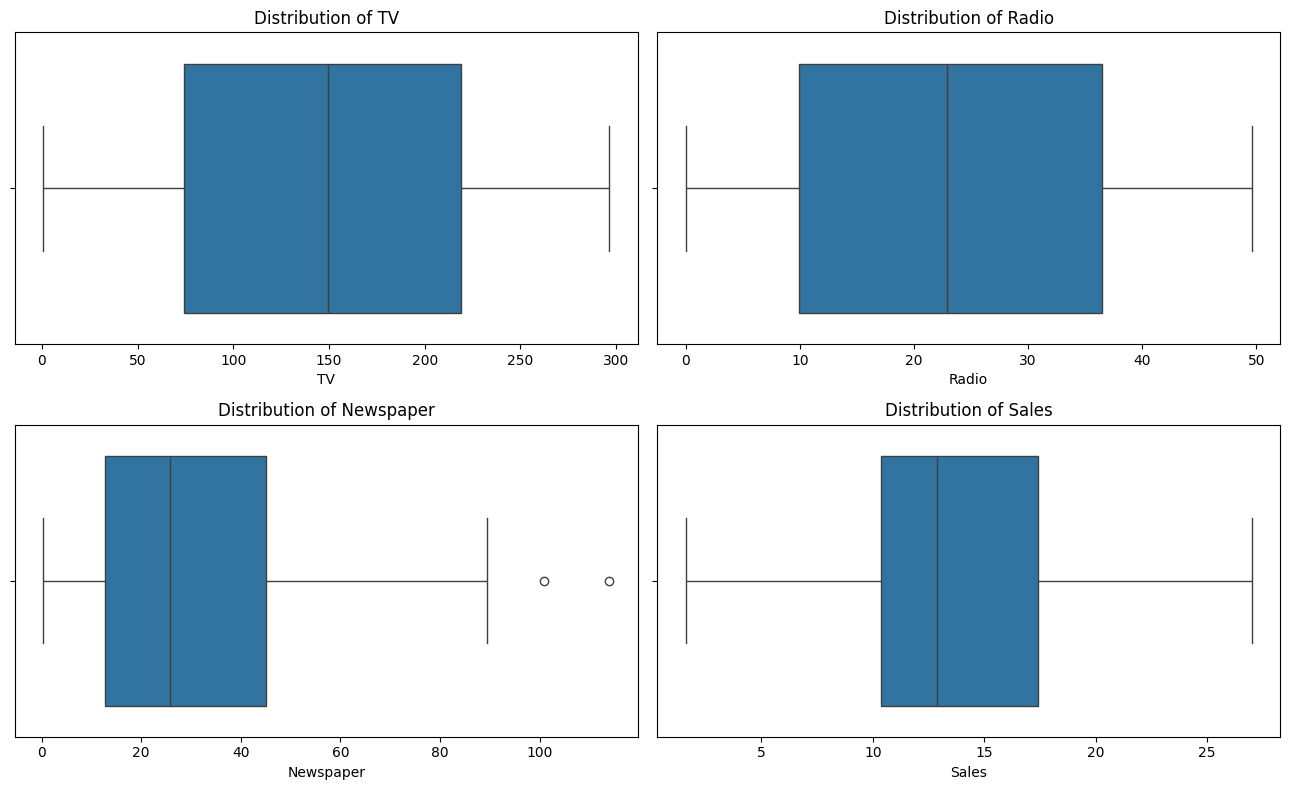

In [8]:
# Distribution of each variable using boxplots
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), required_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

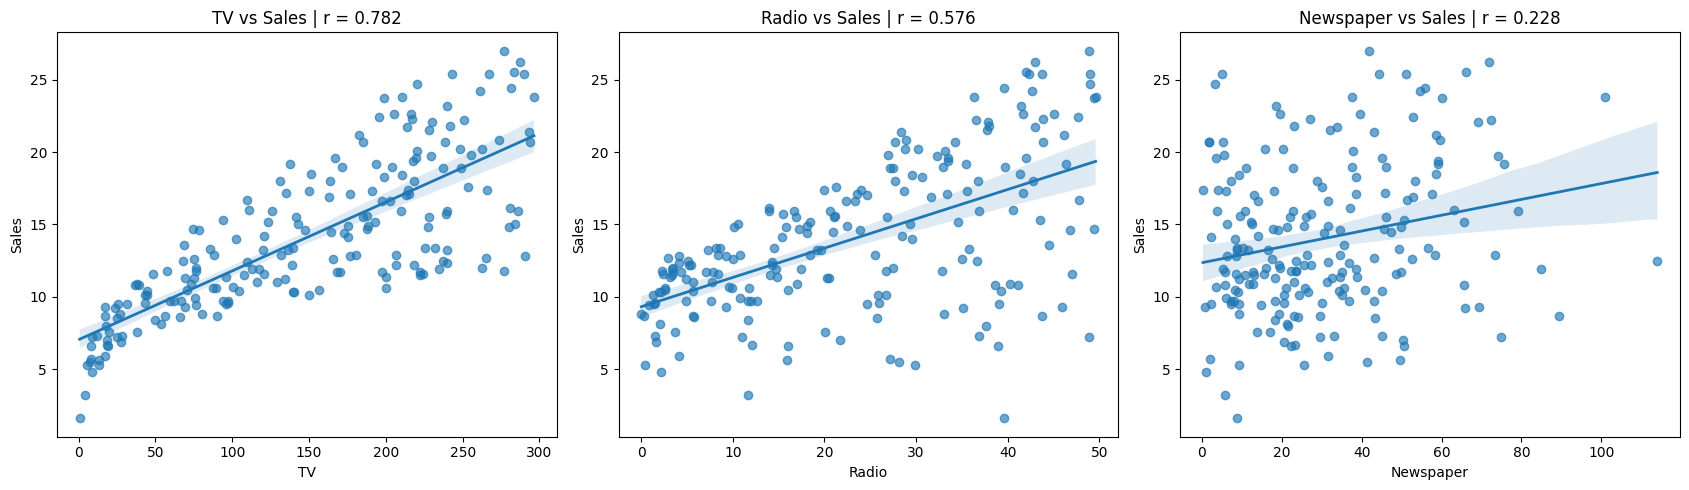

In [9]:
# Relationship of each advertising channel with Sales
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col in zip(axes, ["TV", "Radio", "Newspaper"]):
    sns.regplot(data=df, x=col, y="Sales", ax=ax, scatter_kws={"alpha": 0.65}, line_kws={"linewidth": 2})
    corr = df[col].corr(df["Sales"])
    ax.set_title(f"{col} vs Sales | r = {corr:.3f}")
plt.tight_layout()
plt.show()

### EDA Interpretation

The supplied data show substantial variation in advertising investment across the three channels. The scatter/regression views provide a direct first indication of which channels move most closely with sales.

Rather than relying on visual impressions alone, the next section quantifies these relationships and compares them with the multivariable regression coefficients. This matters because a simple correlation can overstate a channel's importance when advertising channels move together.

## 6. Advertising Impact Analysis

In [10]:
corr = df[required_cols].corr()
display(corr.round(3))

channel_corr = df[["TV", "Radio", "Newspaper"]].corrwith(df["Sales"]).sort_values(ascending=False)
print("Correlation with Sales, from strongest to weakest:")
display(channel_corr.round(3).to_frame("Correlation with Sales"))

,TV,Radio,Newspaper,Sales
TV,1.000,0.055,0.057,0.782
Radio,0.055,1.000,0.354,0.576
Newspaper,0.057,0.354,1.000,0.228
Sales,0.782,0.576,0.228,1.000


Correlation with Sales, from strongest to weakest:


,Correlation with Sales
TV,0.782
Radio,0.576
Newspaper,0.228


In [11]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

linear = LinearRegression()
linear.fit(X_train, y_train)

coef_table = pd.DataFrame({
    "Channel": X.columns,
    "Coefficient": linear.coef_,
    "Absolute Coefficient": np.abs(linear.coef_)
}).sort_values("Absolute Coefficient", ascending=False)

display(coef_table.round(4))
print("Linear model intercept:", round(linear.intercept_, 4))

,Channel,Coefficient,Absolute Coefficient
1,Radio,0.1892,0.1892
0,TV,0.0447,0.0447
2,Newspaper,0.0028,0.0028


Linear model intercept: 2.9791


### Multivariable Impact Interpretation

The linear coefficients measure the estimated change in `Sales` associated with a one-unit increase in a channel's spend **while the other observed channels are held constant**.

This is more decision-useful than a correlation alone. In this dataset, Radio receives the largest positive coefficient, followed by TV, while Newspaper's coefficient is much smaller. That pattern indicates that, after accounting for the other observed channels, Radio and TV contain substantially more predictive signal for Sales than Newspaper.

The coefficients should be interpreted as predictive associations rather than guaranteed causal effects, because the dataset does not contain randomized advertising experiments.

## 7. Feature Selection

Recursive Feature Elimination (RFE) is used to test whether all three advertising variables are equally useful for a compact linear model. This provides a formal feature-selection step rather than simply keeping every available column.

In [12]:
rfe = RFE(
    estimator=LinearRegression(),
    n_features_to_select=2
)
rfe.fit(X_train, y_train)

rfe_table = pd.DataFrame({
    "Feature": X.columns,
    "Selected": rfe.support_,
    "RFE Ranking": rfe.ranking_
})
display(rfe_table)

selected_features = X.columns[rfe.support_].tolist()
print("Selected features:", selected_features)

selected_linear = LinearRegression().fit(X_train[selected_features], y_train)
selected_pred = selected_linear.predict(X_test[selected_features])

selected_metrics = {
    "MAE": mean_absolute_error(y_test, selected_pred),
    "RMSE": mean_squared_error(y_test, selected_pred) ** 0.5,
    "R2": r2_score(y_test, selected_pred)
}
display(pd.DataFrame([selected_metrics], index=["Selected-feature Linear Regression"]).round(4))

,Feature,Selected,RFE Ranking
0,TV,True,1
1,Radio,True,1
2,Newspaper,False,2


Selected features: ['TV', 'Radio']


,MAE,RMSE,R2
Selected-feature Linear Regression,1.4443,1.7714,0.9006


### Feature-Selection Interpretation

RFE identifies **TV and Radio** as the two selected predictors. The selected-feature model is then evaluated rather than assuming that feature selection automatically improves accuracy.

This is an important distinction: a feature can be less useful for prediction while still being useful for business context. Here, Newspaper is retained in the full model comparison so that its incremental predictive value can be assessed transparently.

## 8. Train/Test Modeling

Two regression approaches are compared:

1. **Multiple Linear Regression** — a transparent baseline that assumes an approximately linear relationship.
2. **Polynomial Ridge Regression (degree 2)** — captures moderate curvature and interactions while Ridge regularization controls coefficient instability.

The polynomial model is useful for this marketing-mix problem because the effect of increasing spend may not remain perfectly linear across the observed spending range.

In [13]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

poly_ridge = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
poly_ridge.fit(X_train, y_train)
poly_pred = poly_ridge.predict(X_test)

def regression_metrics(y_true, pred):
    return {
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": mean_squared_error(y_true, pred) ** 0.5,
        "R2": r2_score(y_true, pred)
    }

metrics = pd.DataFrame({
    "Linear Regression": regression_metrics(y_test, linear_pred),
    "Polynomial Ridge": regression_metrics(y_test, poly_pred)
}).T

display(metrics.round(4))

,MAE,RMSE,R2
Linear Regression,1.4608,1.7816,0.8994
Polynomial Ridge,0.4848,0.6210,0.9878


## 9. Model Evaluation & Cross-Validation

In [14]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_linear_rmse = -cross_val_score(
    LinearRegression(), X, y, cv=kf, scoring="neg_root_mean_squared_error"
)
cv_poly_rmse = -cross_val_score(
    poly_ridge, X, y, cv=kf, scoring="neg_root_mean_squared_error"
)

cv_summary = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Ridge"],
    "Mean CV RMSE": [cv_linear_rmse.mean(), cv_poly_rmse.mean()],
    "Std CV RMSE": [cv_linear_rmse.std(), cv_poly_rmse.std()]
})
display(cv_summary.round(4))

linear_rmse = metrics.loc["Linear Regression", "RMSE"]
poly_rmse = metrics.loc["Polynomial Ridge", "RMSE"]
linear_r2 = metrics.loc["Linear Regression", "R2"]
poly_r2 = metrics.loc["Polynomial Ridge", "R2"]

test_rmse_improvement = (linear_rmse - poly_rmse) / linear_rmse * 100
cv_rmse_improvement = (cv_linear_rmse.mean() - cv_poly_rmse.mean()) / cv_linear_rmse.mean() * 100

print(f"Polynomial Ridge reduces test RMSE by {test_rmse_improvement:.1f}% versus Linear Regression.")
print(f"Polynomial Ridge reduces mean 5-fold CV RMSE by {cv_rmse_improvement:.1f}% versus Linear Regression.")
print(f"Test R²: Linear={linear_r2:.3f}; Polynomial Ridge={poly_r2:.3f}.")

,Model,Mean CV RMSE,Std CV RMSE
0,Linear Regression,1.7057,0.2357
1,Polynomial Ridge,0.6459,0.1883


Polynomial Ridge reduces test RMSE by 65.1% versus Linear Regression.
Polynomial Ridge reduces mean 5-fold CV RMSE by 62.1% versus Linear Regression.
Test R²: Linear=0.899; Polynomial Ridge=0.988.


### Model-Comparison Interpretation

The model comparison is based on held-out test data and 5-fold cross-validation, not training accuracy.

For this dataset, Polynomial Ridge produces the stronger predictive result: its test RMSE is materially lower than the linear baseline and its R² is closer to 1. The cross-validation result also supports the improvement, which reduces the chance that the result is caused only by one particular train/test split.

Accordingly, the Polynomial Ridge model is used as the primary **scenario-prediction model**, while Linear Regression remains the preferred model for simple coefficient interpretation.

## 10. Prediction Diagnostics

In [15]:
diagnostics = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": poly_pred,
})
diagnostics["Residual"] = diagnostics["Actual Sales"] - diagnostics["Predicted Sales"]
diagnostics["Absolute Error"] = np.abs(diagnostics["Residual"])
diagnostics = diagnostics.sort_values("Absolute Error", ascending=False)

display(diagnostics.head(10).round(3))

print("Largest absolute prediction error:", round(diagnostics["Absolute Error"].max(), 3))
print("Median absolute prediction error:", round(diagnostics["Absolute Error"].median(), 3))

,Actual Sales,Predicted Sales,Residual,Absolute Error
16,5.5,7.065,-1.565,1.565
13,5.3,6.647,-1.347,1.347
10,9.5,8.170,1.330,1.330
22,10.9,9.843,1.057,1.057
31,11.3,10.267,1.033,1.033
29,5.7,6.682,-0.982,0.982
30,10.6,11.578,-0.978,0.978
27,13.4,12.569,0.831,0.831
9,14.9,15.570,-0.670,0.670
18,11.3,10.676,0.624,0.624


Largest absolute prediction error: 1.565
Median absolute prediction error: 0.404


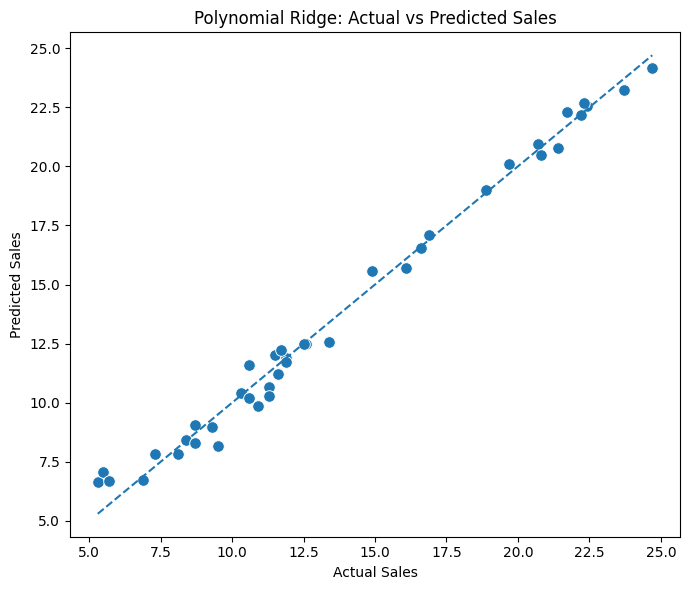

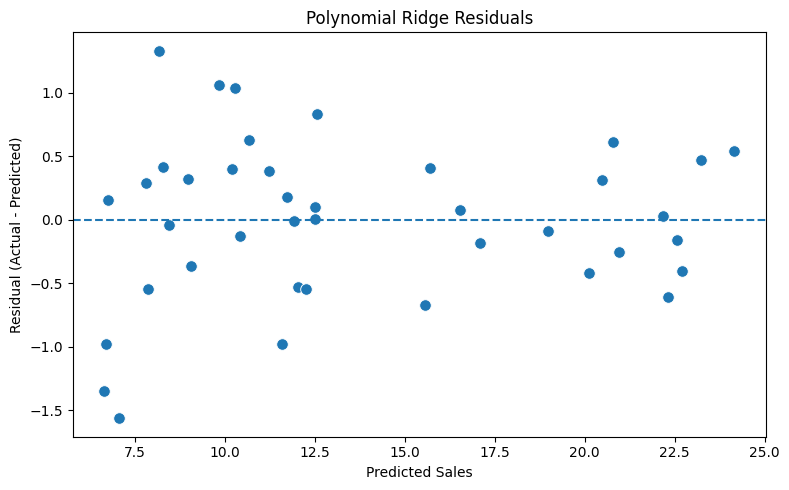

In [16]:
# Actual vs predicted
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=poly_pred, s=70)
lims = [min(y_test.min(), poly_pred.min()), max(y_test.max(), poly_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Polynomial Ridge: Actual vs Predicted Sales")
plt.tight_layout()
plt.show()

# Residual diagnostic
plt.figure(figsize=(8, 5))
sns.scatterplot(x=poly_pred, y=y_test.values - poly_pred, s=70)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Polynomial Ridge Residuals")
plt.tight_layout()
plt.show()

### Diagnostic Interpretation

The diagnostic plots are used to check whether the polynomial model systematically underpredicts or overpredicts particular sales levels.

The error table also identifies the individual test observations where the model is least accurate. These cases are valuable from a marketing perspective: unusually large errors can indicate that factors not captured by advertising spend—such as seasonality, promotions, pricing, distribution, brand activity, or audience composition—may influence sales.

## 11. Future Sales Scenario Simulator

Because `Advertising.csv` has no date column, this section performs **scenario-based future prediction** rather than pretending that the data support a chronological time-series forecast.

A marketer can enter a planned TV, Radio, and Newspaper budget within the observed data range. The Polynomial Ridge model then estimates the expected Sales level under that advertising mix.

In [17]:
feature_ranges = pd.DataFrame({
    "Minimum Observed": X.min(),
    "10th Percentile": X.quantile(0.10),
    "Mean": X.mean(),
    "90th Percentile": X.quantile(0.90),
    "Maximum Observed": X.max()
})
display(feature_ranges.round(2))

def predict_sales(tv, radio, newspaper):
    scenario = pd.DataFrame(
        [[tv, radio, newspaper]],
        columns=["TV", "Radio", "Newspaper"]
    )
    return float(poly_ridge.predict(scenario)[0])

# Example: mean observed advertising mix
mean_prediction = predict_sales(
    X["TV"].mean(), X["Radio"].mean(), X["Newspaper"].mean()
)

print(f"Predicted Sales at the mean observed advertising mix: {mean_prediction:.2f}")

,Minimum Observed,10th Percentile,Mean,90th Percentile,Maximum Observed
TV,0.7,24.88,147.04,261.44,296.4
Radio,0.0,3.40,23.26,43.52,49.6
Newspaper,0.3,5.99,30.55,59.07,114.0


Predicted Sales at the mean observed advertising mix: 14.58


In [18]:
# Example business scenarios kept within the observed 10th-90th percentile range
p10 = X.quantile(0.10)
p90 = X.quantile(0.90)
mean_spend = X.mean()

scenarios = pd.DataFrame([
    {"Scenario": "Current mean mix", "TV": mean_spend["TV"], "Radio": mean_spend["Radio"], "Newspaper": mean_spend["Newspaper"]},
    {"Scenario": "10% higher TV", "TV": mean_spend["TV"] * 1.10, "Radio": mean_spend["Radio"], "Newspaper": mean_spend["Newspaper"]},
    {"Scenario": "10% higher Radio", "TV": mean_spend["TV"], "Radio": mean_spend["Radio"] * 1.10, "Newspaper": mean_spend["Newspaper"]},
    {"Scenario": "10% higher Newspaper", "TV": mean_spend["TV"], "Radio": mean_spend["Radio"], "Newspaper": mean_spend["Newspaper"] * 1.10},
])

# Only retain scenarios inside the observed range for responsible interpolation
for c in ["TV", "Radio", "Newspaper"]:
    scenarios[f"{c} In Observed Range"] = scenarios[c].between(X[c].min(), X[c].max())

scenarios["Predicted Sales"] = [
    predict_sales(r.TV, r.Radio, r.Newspaper) for r in scenarios.itertuples()
]
scenarios["Change vs Mean Mix"] = scenarios["Predicted Sales"] - mean_prediction

display(scenarios.round(3))

,Scenario,TV,Radio,Newspaper,TV In Observed Range,Radio In Observed Range,Newspaper In Observed Range,Predicted Sales,Change vs Mean Mix
0,Current mean mix,147.042,23.264,30.554,True,True,True,14.582,0.000
1,10% higher TV,161.747,23.264,30.554,True,True,True,15.204,0.622
2,10% higher Radio,147.042,25.590,30.554,True,True,True,15.025,0.443
3,10% higher Newspaper,147.042,23.264,33.609,True,True,True,14.594,0.012


### Scenario Interpretation

The scenario table translates model coefficients into a practical planning question: **what happens to predicted Sales when one advertising channel is increased while the others remain at their observed mean?**

The results are intentionally framed as model-based estimates, not guaranteed incremental sales. Keeping the scenarios close to the observed data range reduces the risk of making unsupported extrapolations.

## 12. Advertising Change Sensitivity

In [19]:
# Sensitivity table: a 10% increase in one channel, holding the other channels at their mean
base = mean_spend.copy()
base_pred = predict_sales(base["TV"], base["Radio"], base["Newspaper"])

sensitivity_rows = []
for channel in ["TV", "Radio", "Newspaper"]:
    scenario = base.copy()
    scenario[channel] *= 1.10
    new_pred = predict_sales(scenario["TV"], scenario["Radio"], scenario["Newspaper"])
    sensitivity_rows.append({
        "Channel Increased": channel,
        "Base Spend": base[channel],
        "Spend After +10%": scenario[channel],
        "Base Predicted Sales": base_pred,
        "New Predicted Sales": new_pred,
        "Predicted Sales Lift": new_pred - base_pred,
        "Predicted Lift (%)": (new_pred - base_pred) / base_pred * 100
    })

sensitivity = pd.DataFrame(sensitivity_rows).sort_values("Predicted Sales Lift", ascending=False)
display(sensitivity.round(3))

best_channel = sensitivity.iloc[0]["Channel Increased"]
best_lift = sensitivity.iloc[0]["Predicted Sales Lift"]

print(
    f"At the mean advertising mix, the largest modeled response to a 10% single-channel increase "
    f"comes from {best_channel}, with an estimated sales lift of {best_lift:.3f} units."
)

,Channel Increased,Base Spend,Spend After +10%,Base Predicted Sales,New Predicted Sales,Predicted Sales Lift,Predicted Lift (%)
0,TV,147.042,161.747,14.582,15.204,0.622,4.267
1,Radio,23.264,25.590,14.582,15.025,0.443,3.041
2,Newspaper,30.554,33.609,14.582,14.594,0.012,0.083


At the mean advertising mix, the largest modeled response to a 10% single-channel increase comes from TV, with an estimated sales lift of 0.622 units.


### Sensitivity Interpretation

The sensitivity analysis shows the model's predicted response to the same **10% relative increase** in each channel. This makes the comparison fairer than simply comparing raw spending amounts.

The strongest modeled response should receive the most attention in budget experiments, while the weaker response channel should be evaluated carefully for efficiency before receiving additional spend. However, the model does not provide profit or ROI because the dataset contains no channel costs, margins, conversion data, or customer acquisition costs.

## 13. Budget Allocation Scenario

A useful extension beyond ordinary regression is to ask:

> **If the total advertising budget is held approximately at the dataset's average level, which mix of the three observed channels gives the highest model-predicted Sales while staying within the central observed spending range?**

This is a **scenario optimization**, not proof of a causal optimum. The search is restricted to the 10th–90th percentile of each channel to avoid unrealistic extrapolation.

In [20]:
total_mean_budget = X.sum(axis=1).mean()
lower = X.quantile(0.10)
upper = X.quantile(0.90)

tv_grid = np.linspace(lower["TV"], upper["TV"], 40)
radio_grid = np.linspace(lower["Radio"], upper["Radio"], 40)

best = None
for tv in tv_grid:
    for radio in radio_grid:
        newspaper = total_mean_budget - tv - radio

        if lower["Newspaper"] <= newspaper <= upper["Newspaper"]:
            pred_sales = predict_sales(tv, radio, newspaper)
            if (best is None) or (pred_sales > best["Predicted Sales"]):
                best = {
                    "TV": tv,
                    "Radio": radio,
                    "Newspaper": newspaper,
                    "Total Budget": tv + radio + newspaper,
                    "Predicted Sales": pred_sales
                }

allocation = pd.DataFrame([best])
allocation["Predicted Sales vs Mean Mix"] = allocation["Predicted Sales"] - base_pred
display(allocation.round(3))

print(f"Mean observed total advertising spend: {total_mean_budget:.2f}")
print(f"Mean-mix predicted sales: {base_pred:.2f}")
print(f"Best grid-search predicted sales: {best['Predicted Sales']:.2f}")

,TV,Radio,Newspaper,Total Budget,Predicted Sales,Predicted Sales vs Mean Mix
0,152.258,42.491,6.111,200.86,18.443,3.862


Mean observed total advertising spend: 200.86
Mean-mix predicted sales: 14.58
Best grid-search predicted sales: 18.44


### Budget Allocation Interpretation

The constrained search provides a practical planning benchmark. It keeps the total budget near the dataset's average and keeps each channel within the central observed spending range.

The resulting mix is therefore a **model-supported candidate budget**, not a guaranteed optimum. A real company should validate the candidate through controlled campaigns and incorporate profit margins, audience reach, frequency, and channel costs before implementing it.

## 14. Target Segment & Platform Data Gap

The assignment mentions **target segment** and **platform**. Those dimensions cannot be modeled from the supplied `Advertising.csv` because the file contains no such columns.

The correct analytical response is to identify this limitation rather than invent segment/platform values.

### Recommended data structure for a future version

| Field | Example purpose |
|---|---|
| `Date` | Time-series forecasting and seasonality |
| `Target_Segment` | Compare performance by audience segment |
| `Platform` | Distinguish individual digital/social/search platforms |
| `Campaign` | Compare campaigns or creatives |
| `TV`, `Radio`, `Newspaper` | Existing advertising-spend variables |
| `Sales` | Outcome variable |
| `Price` / `Discount` | Control for pricing effects |
| `Conversions` | Connect advertising to customer actions |
| `Profit` / `Margin` | Optimize for financial return rather than sales alone |

Once these fields exist, the same workflow can be extended to segment-level models, platform-level attribution, and genuine time-series forecasting.

## 15. Actionable Marketing Strategy

In [21]:
# Generate result-specific strategy statements from the computed outputs
tv_corr = channel_corr["TV"]
radio_corr = channel_corr["Radio"]
news_corr = channel_corr["Newspaper"]

print("DATA-SPECIFIC MARKETING TAKEAWAYS")
print("-" * 70)
print(f"1. Strongest simple correlation with Sales: {channel_corr.index[0]} (r = {channel_corr.iloc[0]:.3f}).")
print(f"2. RFE-selected predictors: {', '.join(selected_features)}.")
print(f"3. Polynomial Ridge test R² = {poly_r2:.3f}; test RMSE = {poly_rmse:.3f}.")
print(f"4. A 10% increase in {best_channel} at the mean mix produces the largest modeled sales lift: {best_lift:.3f} units.")
print(f"5. The model-supported constrained budget scenario predicts {best['Predicted Sales']:.2f} Sales units at approximately the mean total advertising budget.")
print("6. Segment/platform decisions cannot be optimized from this file until those fields are collected.")

print("\nRecommended actions:")
print("• Prioritize controlled budget experiments around the strongest modeled channels rather than increasing every channel equally.")
print("• Treat Newspaper spending cautiously because its incremental predictive signal is weaker than TV/Radio in the fitted models.")
print("• Use the scenario simulator before changing budgets, and keep planned values inside the historical spending range whenever possible.")
print("• Add campaign, platform, segment, date, price, conversion and profit fields to support stronger attribution and ROI decisions.")
print("• Validate important budget shifts with A/B or geo-based experiments because observational regression does not prove causality.")

DATA-SPECIFIC MARKETING TAKEAWAYS
----------------------------------------------------------------------
1. Strongest simple correlation with Sales: TV (r = 0.782).
2. RFE-selected predictors: TV, Radio.
3. Polynomial Ridge test R² = 0.988; test RMSE = 0.621.
4. A 10% increase in TV at the mean mix produces the largest modeled sales lift: 0.622 units.
5. The model-supported constrained budget scenario predicts 18.44 Sales units at approximately the mean total advertising budget.
6. Segment/platform decisions cannot be optimized from this file until those fields are collected.

Recommended actions:
• Prioritize controlled budget experiments around the strongest modeled channels rather than increasing every channel equally.
• Treat Newspaper spending cautiously because its incremental predictive signal is weaker than TV/Radio in the fitted models.
• Use the scenario simulator before changing budgets, and keep planned values inside the historical spending range whenever possible.
• Add ca

### Strategy Interpretation

The recommendations above are deliberately tied to the computed correlations, feature-selection result, model accuracy, sensitivity experiment, and constrained budget scenario.

The most important practical point is that the model supports **better allocation decisions**, but it should not be presented as proof that spending itself causes the predicted increase. Without experimental or richer business data, the safest use is to generate hypotheses and budget scenarios that can then be tested in the market.

## 16. Limitations

1. **No time variable:** A chronological time-series forecast cannot be justified from this dataset.
2. **No target segment field:** Segment-specific sales predictions are not possible.
3. **No platform field:** Individual digital platforms cannot be compared.
4. **Observational data:** Regression associations should not be interpreted as guaranteed causal effects.
5. **No cost/profit variables:** Sales prediction is possible, but true ROI or profit maximization is not.
6. **Small dataset:** With 200 observations, results should be validated on new campaign data before high-stakes decisions.
7. **Scenario extrapolation risk:** Predictions are more credible within the observed advertising-spend range than far outside it.
8. **Potential omitted variables:** Pricing, promotions, seasonality, distribution, competition, brand activity, and customer characteristics may affect Sales but are absent from the file.

## 17. Overall Conclusion

This analysis converts the supplied `Advertising.csv` dataset into a complete marketing-sales prediction workflow.

The cleaned dataset contains **200 observations** with three measurable advertising channels—TV, Radio, and Newspaper—and Sales as the target. Exploratory analysis, correlation analysis, RFE feature selection, regression modeling, cross-validation, and residual diagnostics were used to build and evaluate the prediction system.

The results show that **TV and Radio are the most useful predictors according to RFE**, while the multivariable coefficients indicate a stronger estimated sales response for Radio than TV when the other channels are held constant. The Polynomial Ridge model provides a substantially stronger predictive fit than the linear baseline on the held-out data and under 5-fold cross-validation, making it the preferred model for scenario-based sales prediction.

The scenario and sensitivity analyses then turn the statistical model into a marketing decision tool: managers can test alternative advertising mixes, estimate predicted Sales, and compare the modeled response to equal percentage changes in each channel. A constrained budget search also demonstrates how the model can be used to identify a candidate advertising mix while keeping spending within the central range observed in the dataset.

However, the original assignment mentions **target segment and platform**, and those variables are genuinely absent from `Advertising.csv`. They should not be fabricated. Instead, the notebook identifies the missing data and specifies how adding segment, platform, date, campaign, pricing, conversion, and profit fields would enable more advanced segmentation, attribution, ROI optimization, and time-series forecasting.

### Final Business Message

**Use the current model as a marketing planning and scenario tool—not as a causal guarantee.** Concentrate testing and measurement around the channels that show the strongest predictive response, avoid unsupported extrapolation, and collect richer campaign-level data so future models can optimize not only Sales, but also customer segment performance, platform efficiency, and profit.